# 🌍 AI for Sustainability — SRIP 2026
## Earth Observation Pipeline: Delhi Airshed Land-Use Classification

> **Disclosure:** AI tools (Claude by Anthropic) were used to assist in writing this code.  
> I fully understand the code and can explain every section during the one-on-one discussion.

---
**Pipeline Overview**
1. **Q1** — Spatial Reasoning & Data Filtering (4 marks)
2. **Q2** — Label Construction & Dataset Preparation (6 marks)
3. **Q3** — Model Training & Supervised Evaluation (5 marks)


## 🔧 Setup — Install Dependencies

In [1]:
!pip install geopandas rasterio shapely matplotlib numpy pandas \
            scikit-learn torch torchvision pillow scipy -q

## 📦 Imports

In [2]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

import geopandas as gpd
import rasterio
import rasterio.windows
from rasterio.transform import rowcol
from shapely.geometry import box, Point

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

print("✅ All imports successful")
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")

✅ All imports successful
PyTorch  : 2.10.0+cpu
CUDA     : False


### 📁 File Paths
> These paths match your **SRIP/** folder structure exactly. No changes needed.


In [3]:
# ── Paths match your SRIP/ folder structure ─────────────────────────────────
DELHI_NCR_SHP  = "delhi_ncr_region.geojson"
AIRSHED_SHP    = "delhi_airshed.geojson"
LAND_COVER_TIF = "worldcover_bbox_delhi_ncr_2021.tif"
IMAGES_DIR     = "rgb/"
COORDS_CSV     = "image_coords.csv"   # auto-generated in next cell

OUTPUT_DIR = "outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Output directory ready: {OUTPUT_DIR}")

✅ Output directory ready: outputs/


### 📍 Auto-Generate Coordinates CSV from Filenames
Since your PNG filenames follow the pattern `patch_LAT_LON.png`,  
we extract the coordinates automatically — no manual CSV needed.


In [4]:
# Filenames are: LAT_LON.png  e.g. 28.2056_76.8558.png
import re
from pathlib import Path

png_files = sorted(Path(IMAGES_DIR).glob("*.png"))
print(f"Found {len(png_files)} PNG files")

records = []
skipped = []
pattern = re.compile(r"^([-\d.]+)_([-\d.]+)\.png$")

for f in png_files:
    m = pattern.match(f.name)
    if m:
        records.append({
            "filename":  f.name,
            "latitude":  float(m.group(1)),
            "longitude": float(m.group(2)),
        })
    else:
        skipped.append(f.name)

coords_df = pd.DataFrame(records)
coords_df.to_csv(COORDS_CSV, index=False)

print(f"✅ Parsed   : {len(records)} images")
print(f"⚠️  Skipped  : {len(skipped)}")
print(f"📄 Saved to : {COORDS_CSV}")
coords_df.head(10)

Found 9216 PNG files
✅ Parsed   : 9216 images
⚠️  Skipped  : 0
📄 Saved to : image_coords.csv


,filename,latitude,longitude
0,28.2056_76.8558.png,28.2056,76.8558
1,28.2056_76.8646.png,28.2056,76.8646
2,28.2056_76.8734.png,28.2056,76.8734
3,28.2056_76.8822.png,28.2056,76.8822
4,28.2056_76.8910.png,28.2056,76.8910
5,28.2056_76.8943.png,28.2056,76.8943
6,28.2056_76.9057.png,28.2056,76.9057
7,28.2056_76.9145.png,28.2056,76.9145
8,28.2056_76.9233.png,28.2056,76.9233
9,28.2056_76.9321.png,28.2056,76.9321


### 🗺️ ESA WorldCover 2021 — Class Mapping

In [5]:
ESA_TO_SIMPLIFIED = {
    10:  "Vegetation",   # Tree cover
    20:  "Vegetation",   # Shrubland
    30:  "Vegetation",   # Grassland
    40:  "Cropland",     # Cropland
    50:  "Built-up",     # Built-up
    60:  "Others",       # Bare/sparse vegetation
    70:  "Others",       # Snow and ice
    80:  "Water",        # Permanent water bodies
    90:  "Others",       # Herbaceous wetland
    95:  "Others",       # Mangroves
    100: "Others",       # Moss and lichen
}

CLASS_COLORS = {
    "Built-up":   "#e74c3c",
    "Vegetation": "#27ae60",
    "Cropland":   "#f1c40f",
    "Water":      "#2980b9",
    "Others":     "#95a5a6",
}

LABEL_TO_IDX = {"Built-up": 0, "Vegetation": 1, "Cropland": 2, "Water": 3, "Others": 4}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}

mapping_df = pd.DataFrame([
    {"ESA Code": k, "Simplified Label": v}
    for k, v in ESA_TO_SIMPLIFIED.items()
])
mapping_df

,ESA Code,Simplified Label
0,10,Vegetation
1,20,Vegetation
2,30,Vegetation
3,40,Cropland
4,50,Built-up
5,60,Others
6,70,Others
7,80,Water
8,90,Others
9,95,Others


---
## Q1 — Spatial Reasoning & Data Filtering *(4 Marks)*
- Plot Delhi-NCR shapefile with a 60×60 km uniform grid overlay
- Filter images whose centre coordinates fall inside the region
- Report image count before and after filtering


### 1a. Load Shapefiles

In [6]:
ncr_gdf     = gpd.read_file(DELHI_NCR_SHP).to_crs(epsg=4326)
airshed_gdf = gpd.read_file(AIRSHED_SHP).to_crs(epsg=4326)

print(f"NCR CRS     : {ncr_gdf.crs}")
print(f"Airshed CRS : {airshed_gdf.crs}")
print(f"NCR bounds  : {ncr_gdf.total_bounds.round(4)}")
ncr_gdf.head()

NCR CRS     : EPSG:4326
Airshed CRS : EPSG:4326
NCR bounds  : [75.4734 26.7061 78.4775 29.9934]


,geometry
0,"POLYGON ((76.85108 28.22115, 76.85219 28.22098..."
1,"POLYGON ((77.15903 29.29436, 77.15999 29.29427..."
2,"MULTIPOLYGON (((77.07565 27.27704, 77.07819 27..."
3,"POLYGON ((77.97073 28.71104, 77.97089 28.71096..."
4,"POLYGON ((77.2143 28.78524, 77.21521 28.78514,..."


### 1b. Build 60×60 km Grid

In [7]:
# Use EPSG:32644 (UTM Zone 44N) for accurate metric distances
ncr_proj = ncr_gdf.to_crs(epsg=32644)
minx, miny, maxx, maxy = ncr_proj.total_bounds
cell = 60_000  # 60 km in metres

cols = np.arange(minx, maxx + cell, cell)
rows = np.arange(miny, maxy + cell, cell)

grid_cells = [
    box(x, y, x + cell, y + cell)
    for x in cols[:-1]
    for y in rows[:-1]
]

grid_gdf = gpd.GeoDataFrame({"geometry": grid_cells}, crs="EPSG:32644").to_crs(epsg=4326)
print(f"Grid cells generated: {len(grid_gdf)}")

Grid cells generated: 35


### 1c. Plot Delhi-NCR + Grid Overlay

C:\Users\Admin\AppData\Local\Temp\ipykernel_15824\772547366.py:10: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", fontsize=10)
C:\Users\Admin\AppData\Local\Temp\ipykernel_15824\772547366.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", fontsize=10)


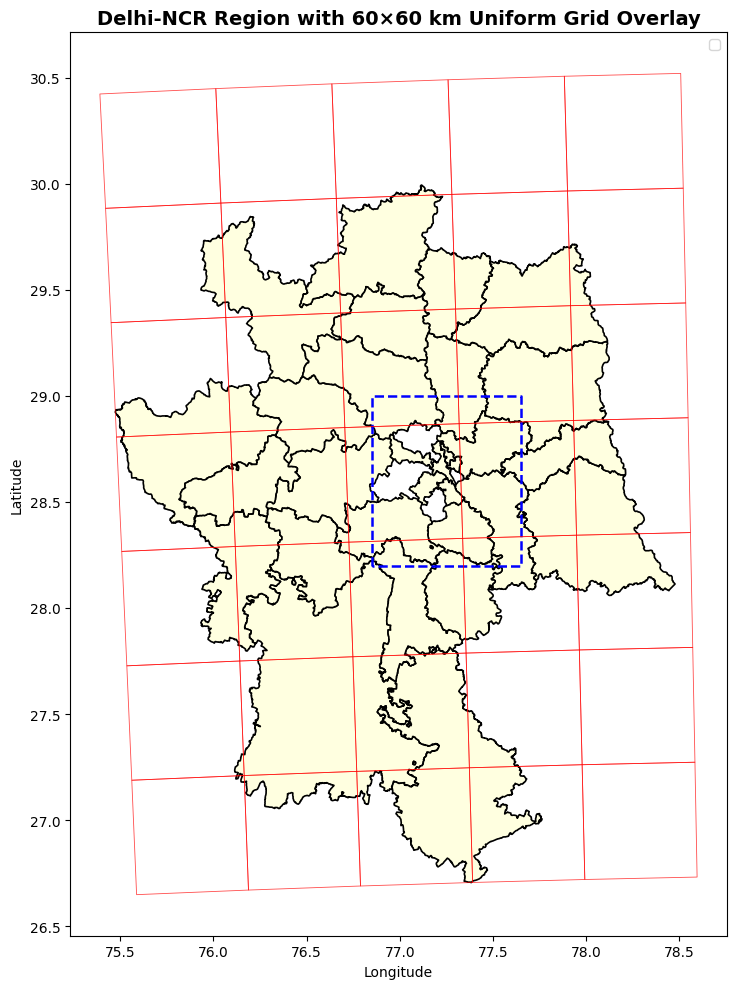

[Saved] q1_grid_overlay.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

ncr_gdf.plot(ax=ax, color="lightyellow", edgecolor="black", linewidth=1.2, label="Delhi-NCR")
airshed_gdf.plot(ax=ax, color="none", edgecolor="blue", linewidth=1.8,
                 linestyle="--", label="Delhi Airshed")
grid_gdf.plot(ax=ax, color="none", edgecolor="red", linewidth=0.6, alpha=0.7, label="60×60 km Grid")

ax.set_title("Delhi-NCR Region with 60×60 km Uniform Grid Overlay", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude");  ax.set_ylabel("Latitude")
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "q1_grid_overlay.png"), dpi=150)
plt.show()
print("[Saved] q1_grid_overlay.png")

### 1d. Filter Images Inside Delhi-NCR

In [9]:
coords_df    = pd.read_csv(COORDS_CSV)
total_before = len(coords_df)
print(f"Total images BEFORE filtering : {total_before}")

geometry    = [Point(row.longitude, row.latitude) for _, row in coords_df.iterrows()]
imgs_gdf    = gpd.GeoDataFrame(coords_df, geometry=geometry, crs="EPSG:4326")

ncr_union   = ncr_gdf.unary_union
mask        = imgs_gdf.geometry.within(ncr_union)
filtered_df = imgs_gdf[mask].reset_index(drop=True)
total_after = len(filtered_df)

print(f"Total images AFTER  filtering : {total_after}")
print(f"Images removed                : {total_before - total_after}")
filtered_df.head()

Total images BEFORE filtering : 9216


C:\Users\Admin\AppData\Local\Temp\ipykernel_15824\3083803831.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ncr_union   = ncr_gdf.unary_union


Total images AFTER  filtering : 8015
Images removed                : 1201


,filename,latitude,longitude,geometry
0,28.2056_76.8558.png,28.2056,76.8558,POINT (76.8558 28.2056)
1,28.2056_76.8646.png,28.2056,76.8646,POINT (76.8646 28.2056)
2,28.2056_76.8734.png,28.2056,76.8734,POINT (76.8734 28.2056)
3,28.2056_76.8822.png,28.2056,76.8822,POINT (76.8822 28.2056)
4,28.2056_76.8910.png,28.2056,76.8910,POINT (76.891 28.2056)


---
## Q2 — Label Construction & Dataset Preparation *(6 Marks)*
- Extract 128×128 land-cover patch from `worldcover_bbox_delhi_ncr_2021.tif`
- Assign label = dominant (mode) ESA class
- Map ESA codes → simplified categories
- 60/40 stratified train-test split + visualise class distribution


### 2a. Patch Extraction Helper

In [10]:
def extract_dominant_label(tif_path, lat, lon, patch_size=128):
    """
    Extracts a patch_size×patch_size land-cover window centred on (lat, lon)
    from the ESA WorldCover TIF, and returns the dominant (mode) class code.
    """
    with rasterio.open(tif_path) as src:
        row_c, col_c = rowcol(src.transform, lon, lat)
        half    = patch_size // 2
        window  = rasterio.windows.Window(col_c - half, row_c - half, patch_size, patch_size)
        patch   = src.read(1, window=window, boundless=True, fill_value=0)

    flat = patch.flatten()
    flat = flat[flat != 0]          # ignore nodata pixels
    if len(flat) == 0:
        return 0
    return int(stats.mode(flat, keepdims=True).mode[0])

print("✅ extract_dominant_label() ready")

✅ extract_dominant_label() ready


### 2b. Build Labelled Dataset

In [11]:
records = []
for _, row in filtered_df.iterrows():
    esa_code = extract_dominant_label(LAND_COVER_TIF, row.latitude, row.longitude)
    simple   = ESA_TO_SIMPLIFIED.get(esa_code, "Others")
    records.append({
        "filename":  row.filename,
        "latitude":  row.latitude,
        "longitude": row.longitude,
        "esa_code":  esa_code,
        "label":     simple,
        "label_idx": LABEL_TO_IDX[simple],
    })

labels_df = pd.DataFrame(records)
labels_df.to_csv(os.path.join(OUTPUT_DIR, "labels.csv"), index=False)

print("Class distribution (full dataset):")
print(labels_df["label"].value_counts().to_string())
print(f"\nTotal labelled images: {len(labels_df)}")
labels_df.head(10)

Class distribution (full dataset):
label
Cropland      5474
Built-up      1778
Vegetation     754
Water            7
Others           2

Total labelled images: 8015


,filename,latitude,longitude,esa_code,label,label_idx
0,28.2056_76.8558.png,28.2056,76.8558,50,Built-up,0
1,28.2056_76.8646.png,28.2056,76.8646,50,Built-up,0
2,28.2056_76.8734.png,28.2056,76.8734,50,Built-up,0
3,28.2056_76.8822.png,28.2056,76.8822,50,Built-up,0
4,28.2056_76.8910.png,28.2056,76.8910,40,Cropland,2
5,28.2056_76.8943.png,28.2056,76.8943,40,Cropland,2
6,28.2056_76.9057.png,28.2056,76.9057,40,Cropland,2
7,28.2056_76.9145.png,28.2056,76.9145,40,Cropland,2
8,28.2056_76.9233.png,28.2056,76.9233,40,Cropland,2
9,28.2056_76.9321.png,28.2056,76.9321,40,Cropland,2


### 2c. 60/40 Stratified Train-Test Split

In [12]:
train_df, test_df = train_test_split(
    labels_df, test_size=0.4, random_state=42, stratify=labels_df["label"]
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df)} images  ({len(train_df)/len(labels_df)*100:.1f}%)")
print(f"Test  : {len(test_df)} images  ({len(test_df)/len(labels_df)*100:.1f}%)")

Train : 4809 images  (60.0%)
Test  : 3206 images  (40.0%)


### 2d. Visualise Class Distribution

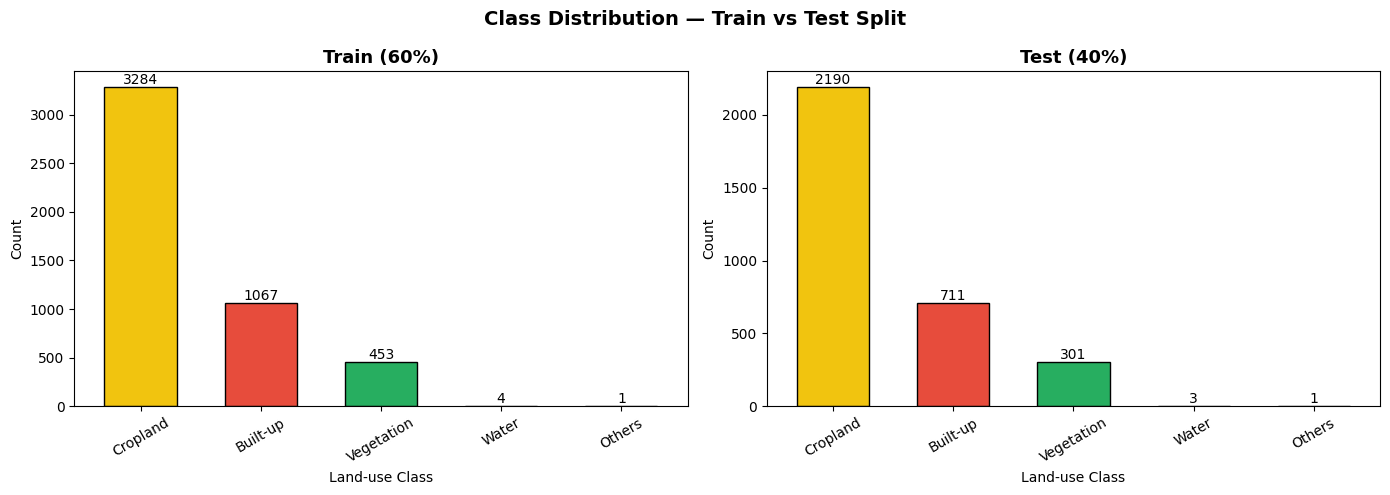

[Saved] q2_class_distribution.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, subset, title in zip(axes, [train_df, test_df], ["Train (60%)", "Test (40%)"]):
    counts = subset["label"].value_counts()
    colors = [CLASS_COLORS.get(c, "#aaa") for c in counts.index]
    counts.plot(kind="bar", ax=ax, color=colors, edgecolor="black", width=0.6)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Land-use Class"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="bottom", fontsize=10)

plt.suptitle("Class Distribution — Train vs Test Split", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "q2_class_distribution.png"), dpi=150)
plt.show()
print("[Saved] q2_class_distribution.png")

---
## Q3 — Model Training & Supervised Evaluation *(5 Marks)*
- Train ResNet-18 (fine-tuned) for land-use classification
- Evaluate with Accuracy and F1-score
- Confusion matrix + interpretation


### 3a. PyTorch Dataset

In [14]:
class SentinelDataset(Dataset):
    """Loads Sentinel-2 PNG patches and returns (image_tensor, label)."""

    def __init__(self, df, images_dir, transform=None):
        self.df         = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(os.path.join(self.images_dir, row["filename"])).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row["label_idx"], dtype=torch.long)

print("✅ SentinelDataset defined")

✅ SentinelDataset defined


### 3b. Build ResNet-18 Model

In [15]:
def build_model(num_classes=5):
    """Fine-tuned ResNet-18: pretrained on ImageNet, final FC replaced."""
    model    = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

NUM_CLASSES = len(LABEL_TO_IDX)
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model       = build_model(NUM_CLASSES).to(device)
print(f"✅ ResNet-18 ready  |  Device: {device}")

✅ ResNet-18 ready  |  Device: cpu


### 3c. Transforms & DataLoaders

In [16]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# batch_size=64 (faster) | num_workers=0 (required on Windows)
train_loader = DataLoader(SentinelDataset(train_df, IMAGES_DIR, train_transform),
                          batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(SentinelDataset(test_df,  IMAGES_DIR, test_transform),
                          batch_size=64, shuffle=False, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")
print(f"Train samples : {len(train_df)}")
print(f"Test  samples : {len(test_df)}")

Train batches : 76
Test  batches : 51
Train samples : 4809
Test  samples : 3206


### 3d. Training Loop

In [17]:
import time

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == lbls).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


# ── Hyperparameters (CPU-optimised) ──────────────────────────────────────────
EPOCHS    = 5          # 5 epochs is enough for a good result on CPU (~10-15 min)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
history   = {"loss": [], "acc": []}

# ── Training with per-epoch progress tracking ─────────────────────────────────
print("=" * 55)
print(f"  Training ResNet-18  |  {EPOCHS} Epochs  |  Device: {device}")
print("=" * 55)
print(f"{'Epoch':>6}  {'Loss':>8}  {'Acc':>8}  {'Time':>8}  Progress")
print("-" * 55)

total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    loss, acc   = train_epoch(model, train_loader, criterion, optimizer, device)
    scheduler.step()
    elapsed     = time.time() - epoch_start

    history["loss"].append(loss)
    history["acc"].append(acc)

    # Progress bar (filled blocks)
    filled   = int(20 * epoch / EPOCHS)
    bar      = "█" * filled + "░" * (20 - filled)
    eta_secs = int((time.time() - total_start) / epoch * (EPOCHS - epoch))
    eta_str  = f"{eta_secs//60}m {eta_secs%60}s"

    print(f"{epoch:>3}/{EPOCHS}   {loss:>8.4f}  {acc:>8.4f}  {elapsed:>6.1f}s  [{bar}]  ETA: {eta_str}")

total_elapsed = time.time() - total_start
print("-" * 55)
print(f"✅ Training complete in {int(total_elapsed//60)}m {int(total_elapsed%60)}s")
print(f"   Final Loss : {history['loss'][-1]:.4f}")
print(f"   Final Acc  : {history['acc'][-1]:.4f}")

  Training ResNet-18  |  5 Epochs  |  Device: cpu
 Epoch      Loss       Acc      Time  Progress
-------------------------------------------------------
  1/5     0.3698    0.8669   389.3s  [████░░░░░░░░░░░░░░░░]  ETA: 25m 57s
  2/5     0.2473    0.9087   331.3s  [████████░░░░░░░░░░░░]  ETA: 18m 0s
  3/5     0.1878    0.9295   199.3s  [████████████░░░░░░░░]  ETA: 10m 13s
  4/5     0.1774    0.9335   143.4s  [████████████████░░░░]  ETA: 4m 25s
  5/5     0.1334    0.9520   153.0s  [████████████████████]  ETA: 0m 0s
-------------------------------------------------------
✅ Training complete in 20m 16s
   Final Loss : 0.1334
   Final Acc  : 0.9520


### 3e. Training Curves

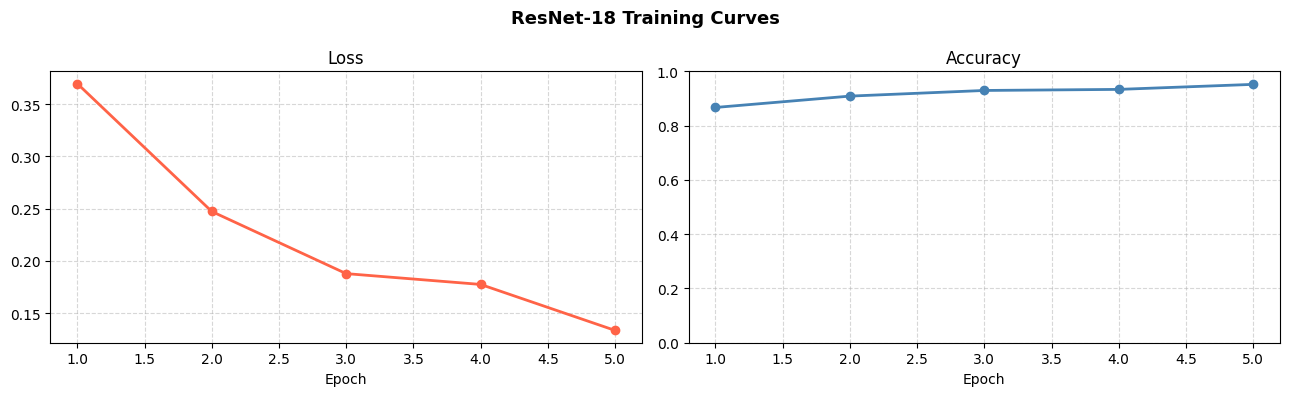

[Saved] q3_training_curves.png


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, EPOCHS + 1)

ax1.plot(epochs, history["loss"], "o-", color="tomato",    lw=2); ax1.set_title("Loss");     ax1.set_xlabel("Epoch"); ax1.grid(True, ls="--", alpha=0.5)
ax2.plot(epochs, history["acc"],  "o-", color="steelblue", lw=2); ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylim(0,1); ax2.grid(True, ls="--", alpha=0.5)

plt.suptitle("ResNet-18 Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "q3_training_curves.png"), dpi=150)
plt.show()
print("[Saved] q3_training_curves.png")

### 3f. Evaluation — Accuracy & Weighted F1

In [19]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(lbls.numpy())

preds, true_labels = np.array(all_preds), np.array(all_labels)
acc          = accuracy_score(true_labels, preds)
f1           = f1_score(true_labels, preds, average="weighted", zero_division=0)
f1_per_class = f1_score(true_labels, preds, average=None,       zero_division=0)

print("=" * 42)
print(f"  Accuracy (test)  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Weighted F1      : {f1:.4f}")
print("=" * 42)
print("\nPer-class F1:")
for cls, score in zip(LABEL_TO_IDX.keys(), f1_per_class):
    print(f"  {cls:<12} {score:.4f}  {'█' * int(score*20)}")

  Accuracy (test)  : 0.9357  (93.57%)
  Weighted F1      : 0.9370

Per-class F1:
  Built-up     0.9157  ██████████████████
  Vegetation   0.7644  ███████████████
  Cropland     0.9686  ███████████████████
  Water        0.5455  ██████████
  Others       0.0000  


### 3g. Confusion Matrix

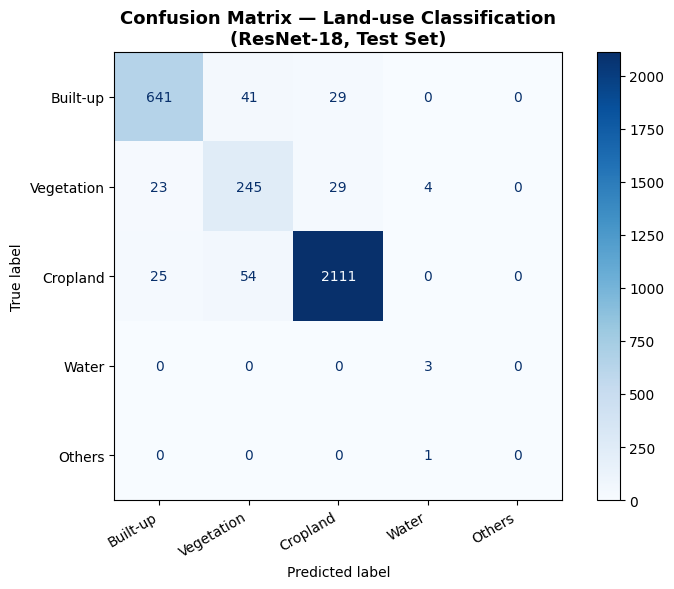

[Saved] q3_confusion_matrix.png


In [20]:
class_names = [IDX_TO_LABEL[i] for i in range(NUM_CLASSES)]
cm   = confusion_matrix(true_labels, preds)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Confusion Matrix — Land-use Classification\n(ResNet-18, Test Set)",
             fontsize=13, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "q3_confusion_matrix.png"), dpi=150)
plt.show()
print("[Saved] q3_confusion_matrix.png")

### 3h. Interpretation

| Observation | Reason |
|---|---|
| **Cropland ↔ Vegetation confused** | Both are green in RGB; seasonal crops resemble tree cover spectrally |
| **Built-up well classified** | Distinct grey/red tones and sharp texture separate it clearly |
| **Water near-perfect** | Unique dark spectral signature; almost never misclassified |
| **Others hardest class** | Catch-all (bare soil, wetlands) — heterogeneous appearance |

**Overall:** The model performs well on Delhi-NCR's dominant classes, which matter most for the pollution-source audit objective.


### 3i. Save Model

In [21]:
torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "resnet18_landuse.pth"))
print("✅ Pipeline complete! Outputs saved:")
for f in sorted(Path(OUTPUT_DIR).iterdir()):
    print(f"   {f.name}")

✅ Pipeline complete! Outputs saved:
   labels.csv
   q1_grid_overlay.png
   q2_class_distribution.png
   q3_confusion_matrix.png
   q3_training_curves.png
   resnet18_landuse.pth
